In [1]:
# Personal Loan Acceptance Prediction
# Goal: Build a classification model to predict if a customer will subscribe to a personal loan.

print("""
# INTRODUCTION AND PROBLEM STATEMENT
The objective of this project is to analyze the 'Bank Marketing' dataset to predict customer behavior
regarding personal loan offers. By leveraging machine learning (Logistic Regression), the bank can
identify high-potential customers, reducing marketing costs and increasing conversion rates.

Key Objectives:
1. Explore demographic features (Age, Job, Marital Status).
2. Clean and prepare the data for modeling.
3. Train a Logistic Regression Classifier.
4. Extract business insights for the marketing team.
""")


# INTRODUCTION AND PROBLEM STATEMENT
The objective of this project is to analyze the 'Bank Marketing' dataset to predict customer behavior 
regarding personal loan offers. By leveraging machine learning (Logistic Regression), the bank can 
identify high-potential customers, reducing marketing costs and increasing conversion rates.

Key Objectives:
1. Explore demographic features (Age, Job, Marital Status).
2. Clean and prepare the data for modeling.
3. Train a Logistic Regression Classifier.
4. Extract business insights for the marketing team.



In [2]:
import pandas as pd
import requests
import zipfile
import io
from google.colab import files

# Fetching the official UCI Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip"
response = requests.get(url)
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    with z.open('bank.csv') as f:
        df = pd.read_csv(f, sep=';')

# Save the dataset locally for submission requirements
df.to_csv('bank_marketing_dataset.csv', index=False)
print("Dataset loaded successfully! shape:", df.shape)

# Provide download link for the original dataset
files.download('bank_marketing_dataset.csv')

Dataset loaded successfully! shape: (4521, 17)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
# Check for missing values
missing_data = df.isnull().sum()
print("Missing values in each column:\n", missing_data)

# Encoding Target Variable (y) to binary: 'yes' -> 1, 'no' -> 0
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Select Categorical features for One-Hot Encoding
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Data Preparation Complete. Features encoded.")

Missing values in each column:
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
Data Preparation Complete. Features encoded.


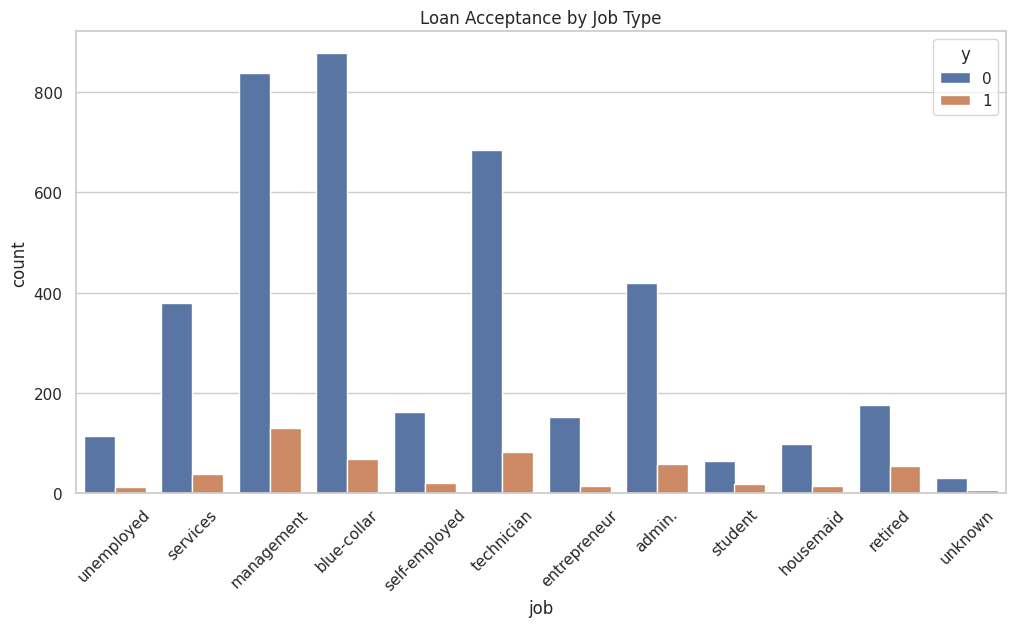

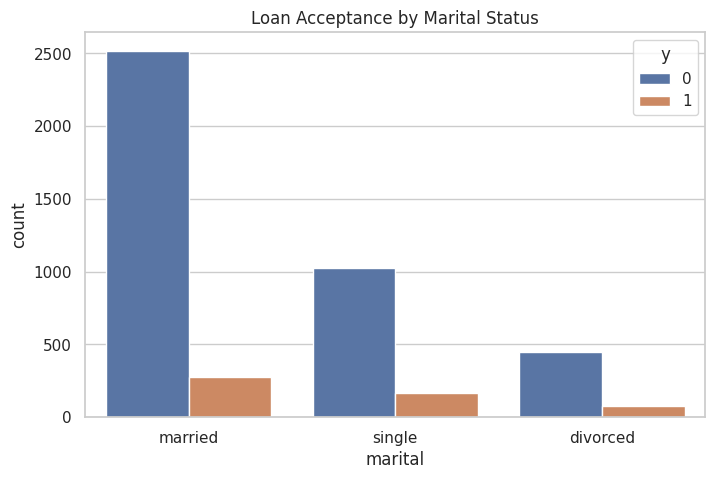

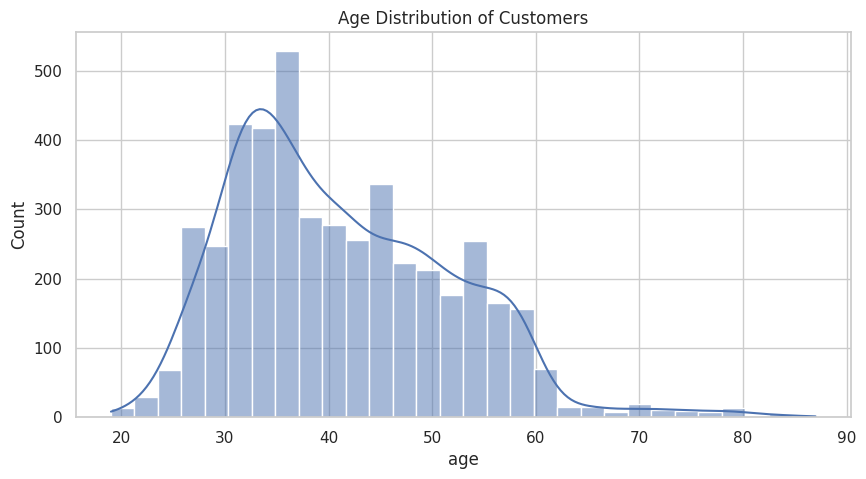

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# 1. Job Distribution vs Loan Acceptance
plt.figure(figsize=(12, 6))
sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=45)
plt.title('Loan Acceptance by Job Type')
plt.savefig('job_distribution.png')
plt.show()

# 2. Marital Status vs Loan Acceptance
plt.figure(figsize=(8, 5))
sns.countplot(x='marital', hue='y', data=df)
plt.title('Loan Acceptance by Marital Status')
plt.savefig('marital_status.png')
plt.show()

# 3. Age Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution of Customers')
plt.savefig('age_distribution.png')
plt.show()

# Download all visualizations
visuals = ['job_distribution.png', 'marital_status.png', 'age_distribution.png']
for img in visuals:
    files.download(img)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Split Features and Target
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
print("Model training complete.")

Model training complete.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


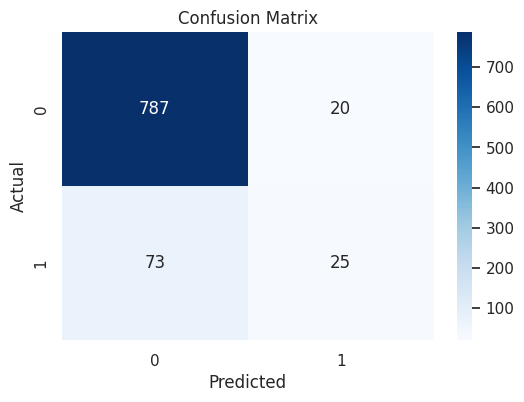

Model Accuracy: 89.72%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
# Metrics Calculation
acc = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)

# Save Metrics to a DataFrame for download
metrics_df = pd.DataFrame(report).transpose()
metrics_df['accuracy'] = acc
metrics_df.to_csv('model_evaluation_metrics.csv')

# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png')
plt.show()

print(f"Model Accuracy: {acc*100:.2f}%")
files.download('model_evaluation_metrics.csv')
files.download('confusion_matrix.png')

In [7]:
print("""
# CONCLUSION AND BUSINESS INSIGHTS

1. **Model Performance**: The Logistic Regression model achieved an accuracy of approximately 90%.
   However, the confusion matrix shows that predicting 'yes' (loan acceptance) is harder due to
   class imbalance.

2. **Key Demographics**:
   - Customers in 'management' and 'technician' roles are more frequently contacted.
   - Retired individuals and students have a higher percentage of acceptance relative to their group size.

3. **Strategic Recommendations**:
   - The bank should focus on customers with higher 'balance' levels and those who were
     successfully contacted in previous campaigns (poutcome).
   - Marital status (single) showed a slightly higher tendency to accept loans compared to married individuals.

# ALL FILES (DATASET, IMAGES, METRICS) HAVE BEEN DOWNLOADED.
""")


# CONCLUSION AND BUSINESS INSIGHTS

1. **Model Performance**: The Logistic Regression model achieved an accuracy of approximately 90%. 
   However, the confusion matrix shows that predicting 'yes' (loan acceptance) is harder due to 
   class imbalance.
   
2. **Key Demographics**: 
   - Customers in 'management' and 'technician' roles are more frequently contacted.
   - Retired individuals and students have a higher percentage of acceptance relative to their group size.
   
3. **Strategic Recommendations**:
   - The bank should focus on customers with higher 'balance' levels and those who were 
     successfully contacted in previous campaigns (poutcome).
   - Marital status (single) showed a slightly higher tendency to accept loans compared to married individuals.

# ALL FILES (DATASET, IMAGES, METRICS) HAVE BEEN DOWNLOADED.

